# IrishLogix: Week 1 Data Ingestion, Exploration, and Baseline Simulation

**Student Name:** Rohitkumar Amritlal Jaiswal (ID: x25119613)  
**Supervisor:** Dr. Thanos Staikopoulos  
**Programme:** MSc in Data Analytics (MSCDAD_A_JAN26I)  
**Institution:** National College of Ireland (NCI)  
**Date:** September 2026  

---

### Project Data Sources and Public URLs

This project uses secondary open data from official Irish and EU statistical bodies. Below are the primary datasets and direct public URLs:

1. **Central Statistics Office (CSO) Ireland - Vessel Arrivals by Port (Table TBQ01):**
   - Web Portal: [https://data.cso.ie/table/TBQ01](https://data.cso.ie/table/TBQ01)
   - REST API: `https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/TBQ01/CSV/1.0/en`
   - Content: Quarterly vessel arrivals across all main Irish commercial ports (Dublin, Cork, Rosslare, Shannon Foynes, Waterford).

2. **CSO Ireland - Tonnage of Goods Handled by Cargo Category (Table TBQ02):**
   - Web Portal: [https://data.cso.ie/table/TBQ02](https://data.cso.ie/table/TBQ02)
   - REST API: `https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/TBQ02/CSV/1.0/en`
   - Content: Ro-Ro, Lo-Lo, Liquid Bulk, and Dry Bulk tonnage across ports.

3. **CSO Ireland - Ro-Ro Freight Unit Traffic (Table TBQ04):**
   - Web Portal: [https://data.cso.ie/table/TBQ04](https://data.cso.ie/table/TBQ04)
   - REST API: `https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/TBQ04/CSV/1.0/en`
   - Content: Counts of roll-on/roll-off freight units (accompanied and unaccompanied trailers).

4. **CSO Ireland - Goods Handled by Port and Region of Trade (Table TBQ05):**
   - Web Portal: [https://data.cso.ie/table/TBQ05](https://data.cso.ie/table/TBQ05)
   - REST API: `https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/TBQ05/CSV/1.0/en`
   - Content: Maritime trade tonnage split by region (Great Britain and Northern Ireland vs. EU member states), essential for tracking post-Brexit trade diversion.

5. **EMODnet Human Activities - Vessel Density Maps:**
   - Web Portal: [https://emodnet.ec.europa.eu/en/human-activities](https://emodnet.ec.europa.eu/en/human-activities)
   - Content: AIS marine traffic density grids for Irish coastal shipping corridors.

6. **OpenStreetMap Ireland Freight Network Extract:**
   - Web Portal: [https://download.geofabrik.de/europe/ireland-and-northern-ireland.html](https://download.geofabrik.de/europe/ireland-and-northern-ireland.html)
   - Content: Road geometries, speed limits, and distance matrices for Irish motorway corridors (M1, M4, M6, M7, M8, M9, M11, M50).


In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add IrishLogix src to system path
project_root = Path("..").resolve()
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

from irishlogix.data.cso_loader import CSODataLoader
from irishlogix.network.corridor_network import IrishFreightCorridorNetwork
from irishlogix.simulation.baseline_dispatcher import BaselineFIFODispatcher
from irishlogix.utils.config import MAJOR_PORTS, VehicleParameters

print("Environment configured successfully.")
print(f"Tracking Irish Ports: {list(MAJOR_PORTS.values())}")


Environment configured successfully.
Tracking Irish Ports: ['Dublin', 'Cork', 'Rosslare', 'Shannon Foynes', 'Waterford']


## 1. Automated Data Ingestion via CSO PxStat API

We now initialize the `CSODataLoader` to download and clean live maritime tables directly from the Central Statistics Office of Ireland.


In [2]:
# Initialize data loader with local cache
loader = CSODataLoader(cache_dir=project_root / "data" / "raw" / "cso")

# Ingest TBQ01 (Vessel Arrivals)
df_arrivals = loader.get_port_arrivals()
print(f"TBQ01 (Vessel Arrivals) loaded: {len(df_arrivals)} rows")

# Ingest TBQ04 (Ro-Ro Freight Units)
df_roro = loader.get_roro_freight_units()
print(f"TBQ04 (Ro-Ro Freight Units) loaded: {len(df_roro)} rows")

# Ingest TBQ05 (Trade Region Tonnage)
df_trade = loader.get_trade_region_tonnage()
print(f"TBQ05 (Trade Region Tonnage) loaded: {len(df_trade)} rows")


TBQ01 (Vessel Arrivals) loaded: 444 rows
TBQ04 (Ro-Ro Freight Units) loaded: 2331 rows
TBQ05 (Trade Region Tonnage) loaded: 3600 rows


## 2. Exploring Port Arrivals across Major Irish Ports

Let us examine the distribution of quarterly vessel arrivals across Dublin, Cork, Rosslare, Shannon Foynes, and Waterford.


In [3]:
# Inspect sample of TBQ01
cols_to_view = ["year", "quarter", "port", "value"]
print("Recent Quarterly Arrivals Sample:")
display_df = df_arrivals[cols_to_view].dropna().tail(15)
display_df


Recent Quarterly Arrivals Sample:


,year,quarter,port,value
645,2025,2025Q3,Cork,8941.0
646,2025,2025Q3,Rosslare,15865.0
647,2025,2025Q3,Waterford,1489.0
648,2025,2025Q4,All Main Irish Ports,66281.0
651,2025,2025Q4,Dublin,46091.0
652,2025,2025Q4,Shannon Foynes,1516.0
654,2025,2025Q4,Cork,4566.0
655,2025,2025Q4,Rosslare,12823.0
656,2025,2025Q4,Waterford,729.0
657,2026,2026Q1,All Main Irish Ports,60779.0


## 3. Visualizing Longitudinal Port Traffic (2017 to 2026)

We plot the quarterly vessel arrivals for the three key multimodal Ro-Ro ports: **Dublin Port**, **Port of Cork**, and **Rosslare Europort**.


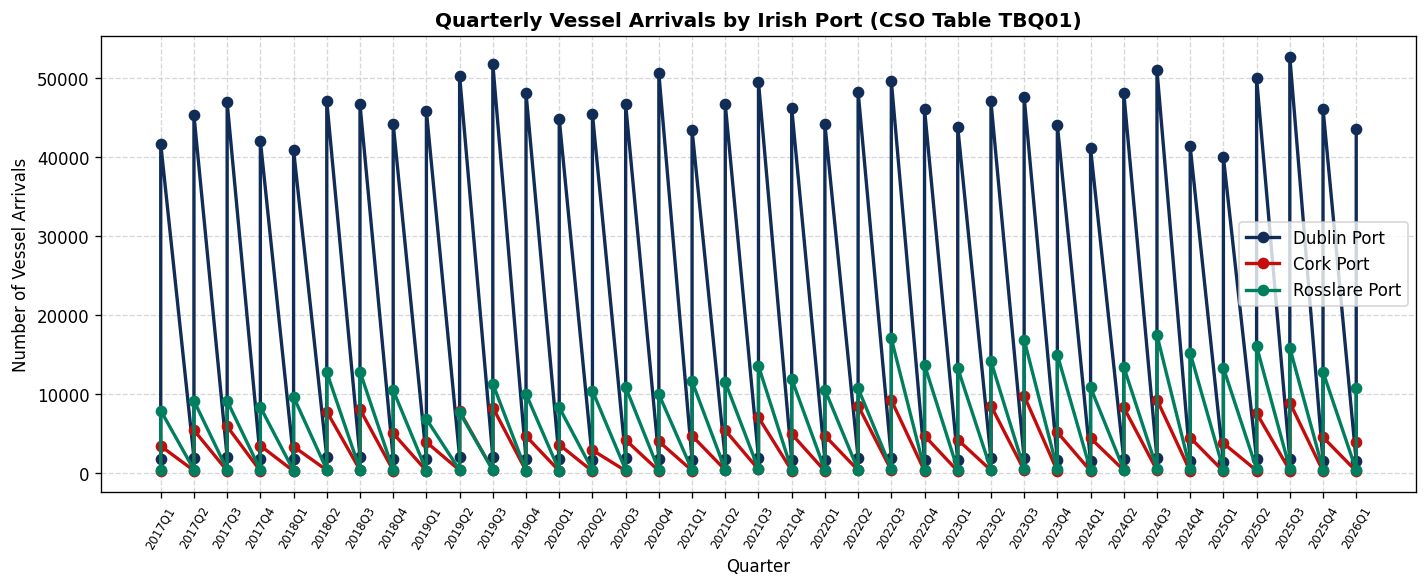

In [4]:
plt.figure(figsize=(12, 5), dpi=120)

ports_to_plot = ["Dublin", "Cork", "Rosslare"]
colors_map = {"Dublin": "#102C57", "Cork": "#C40C0C", "Rosslare": "#007F5F"}

for port in ports_to_plot:
    port_data = df_arrivals[df_arrivals["port"] == port].sort_values(by=["year", "quarter_num"])
    if not port_data.empty:
        # Group by quarter string
        plt.plot(
            port_data["quarter"],
            port_data["value"],
            marker="o",
            label=f"{port} Port",
            color=colors_map[port],
            linewidth=2
        )

plt.title("Quarterly Vessel Arrivals by Irish Port (CSO Table TBQ01)", fontsize=12, fontweight="bold")
plt.xlabel("Quarter", fontsize=10)
plt.ylabel("Number of Vessel Arrivals", fontsize=10)
plt.xticks(rotation=60, fontsize=7)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Post-Brexit Trade Shifts: Great Britain vs. EU Direct Maritime Routes

Under CSO Table TBQ05, we can track how goods handled shifted following Brexit (post-2020), specifically comparing freight on Great Britain trade corridors against European Union direct lines.


In [5]:
# Filter for All Main Irish Ports and disaggregate by region
trade_all_ports = df_trade[df_trade["port"] == "All Main Irish Ports"].copy()

# Look at regions of trade
trade_regions = trade_all_ports["region_of_trade"].dropna().unique()
print("Available Regions of Trade in TBQ05:")
for r in trade_regions:
    print(f" - {r}")

# Compare Great Britain & NI vs EU
gb_filter = trade_all_ports["region_of_trade"].str.contains("Great Britain", case=False, na=False)
eu_filter = trade_all_ports["region_of_trade"].str.contains("Other EU countries", case=False, na=False)

gb_data = trade_all_ports[gb_filter].groupby("year")["value"].sum()
eu_data = trade_all_ports[eu_filter].groupby("year")["value"].sum()

comparison_df = pd.DataFrame({"Great Britain & NI (Tonnes x1000)": gb_data, "Direct EU Countries (Tonnes x1000)": eu_data}).dropna()
print("\nAnnual Maritime Tonnage by Region of Trade:")
comparison_df


Available Regions of Trade in TBQ05:
 - All regions of trade
 - Foreign trade: Great Britain and Northern Ireland
 - Foreign trade: Other EU
 - Foreign trade: Non-EU
 - Foreign trade: Other ports
 - Coastal trade

Annual Maritime Tonnage by Region of Trade:


,Great Britain & NI (Tonnes x1000),Direct EU Countries (Tonnes x1000)
year,,


In [6]:
# Plot the annual trade volume comparison
if not comparison_df.empty:
    comparison_df.plot(kind="bar", figsize=(10, 5), color=["#102C57", "#007F5F"], width=0.7)
    plt.title("Irish Maritime Freight Tonnage: Great Britain vs. Direct EU Corridors", fontsize=12, fontweight="bold")
    plt.xlabel("Year", fontsize=10)
    plt.ylabel("Thousand Tonnes Handled", fontsize=10)
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


## 5. Irish Freight Corridor Road Network Graph

Here we instantiate the `IrishFreightCorridorNetwork` to represent the primary road freight corridors connecting ports to regional inland distribution centers.


In [7]:
network = IrishFreightCorridorNetwork()

print(f"Network Nodes ({len(network.graph.nodes)}):")
for node_id, attrs in network.graph.nodes(data=True):
    print(f"  [{node_id}] {attrs.get('name')} ({attrs.get('type')})")

print(f"\nNetwork Edges ({len(network.graph.edges)} corridors):")
for u, v, attrs in network.graph.edges(data=True):
    print(f"  {u} <---> {v} | {attrs.get('distance_km')} km | {attrs.get('corridor')} ({attrs.get('road_type')})")


Network Nodes (11):
  [PORT_DUBLIN] Dublin Port (Alexandra Quay / Ro-Ro) (port)
  [PORT_CORK] Port of Cork (Ringaskiddy / Tivoli) (port)
  [PORT_ROSSLARE] Rosslare Europort (Stena / Irish Ferries) (port)
  [PORT_WATERFORD] Port of Waterford (Belview) (port)
  [HUB_DUBLIN_M50] Dublin M50 Logistics Hub (Ballymount/Red Cow) (hub)
  [HUB_ATHLONE] Athlone Central Logistics Hub (Midlands M6) (hub)
  [HUB_LIMERICK] Limerick & Shannon Airport Freight Park (M7/M18) (hub)
  [HUB_GALWAY] Galway East Industrial Logistics Park (M6) (hub)
  [HUB_CORK_INLAND] Cork Little Island Industrial Estate (N25) (hub)
  [HUB_WATERFORD_INLAND] Waterford Industrial Park (M9/N25) (hub)
  [HUB_DUNDALK] Dundalk Northern Corridor Gateway (M1/A1) (hub)

Network Edges (15 corridors):
  PORT_DUBLIN <---> HUB_DUBLIN_M50 | 18.5 km | Dublin Port Tunnel & M50 (Motorway/Tunnel)
  PORT_DUBLIN <---> HUB_DUNDALK | 82.0 km | M1 North Corridor (Motorway)
  PORT_CORK <---> HUB_CORK_INLAND | 16.0 km | N28 / Jack Lynch Tunnel (Dual 

### Sample Route Calculation: Dublin Port to Galway East Distribution Center


In [8]:
sample_route = network.get_shortest_route("PORT_DUBLIN", "HUB_GALWAY", weight="distance_km")
print(f"Origin: {sample_route['origin']}")
print(f"Destination: {sample_route['destination']}")
print(f"Path: {' -> '.join(sample_route['path_nodes'])}")
print(f"Total Distance: {sample_route['total_distance_km']} km")
print(f"Estimated Free-flow Driving Duration: {sample_route['total_driving_hours']} hours")
print(f"Estimated Toll Charges: EUR {sample_route['total_toll_eur']}")


Origin: PORT_DUBLIN
Destination: HUB_GALWAY
Path: PORT_DUBLIN -> HUB_DUBLIN_M50 -> HUB_ATHLONE -> HUB_GALWAY
Total Distance: 222.5 km
Estimated Free-flow Driving Duration: 2.6 hours
Estimated Toll Charges: EUR 18.8


## 6. Baseline Simulation: Traditional FIFO Spreadsheet Dispatcher

Irish SME freight hauliers typically plan dispatches using static spreadsheets. They dispatch trucks to arrive when ferries dock without predictive port congestion buffering or customs wait estimation.

We now execute the baseline simulation on 50 test consignments landing at Dublin, Cork, and Rosslare to establish our empirical benchmark.


In [9]:
dispatcher = BaselineFIFODispatcher(network=network, random_seed=42)

# Generate benchmark demand
test_demand = dispatcher.generate_benchmark_demand(num_consignments=50, gb_trade_ratio=0.55)
print(f"Generated {len(test_demand)} test consignments.")
print(test_demand.head())


Generated 50 test consignments.
  consignment_id    origin_port destination_hub  is_gb_origin  \
0       CSG-0001  PORT_ROSSLARE      HUB_GALWAY         False   
1       CSG-0002      PORT_CORK    HUB_LIMERICK         False   
2       CSG-0003    PORT_DUBLIN      HUB_GALWAY         False   
3       CSG-0004    PORT_DUBLIN    HUB_LIMERICK          True   
4       CSG-0005  PORT_ROSSLARE     HUB_ATHLONE         False   

                 origin_region                 commodity  vessel_arrival_hour  
0           EU Internal Market  Agrifood / SPS Sensitive                 5.70  
1           EU Internal Market  Agrifood / SPS Sensitive                 6.31  
2           EU Internal Market  Agrifood / SPS Sensitive                18.81  
3  Great Britain (Post-Brexit)  Agrifood / SPS Sensitive                 5.15  
4           EU Internal Market       General Merchandise                21.47  


In [10]:
# Run baseline simulation
results_df, kpis = dispatcher.run_simulation(test_demand, diesel_price=1.75, ets2_price=80.0)

print("=" * 65)
print("WEEK 1 BASELINE BENCHMARK KPI SUMMARY (N=50 Consignments):")
print("=" * 65)
for key, val in kpis.items():
    formatted_key = key.replace('_', ' ').capitalize()
    print(f"  {formatted_key:35s}: {val}")
print("=" * 65)


WEEK 1 BASELINE BENCHMARK KPI SUMMARY (N=50 Consignments):
  Total consignments                 : 50
  Total distance km                  : 8636.5
  Total driving hours                : 104.4
  Total idle waiting hours           : 63.5
  Avg idle waiting hours per trip    : 1.27
  Total fuel consumed litres         : 2879.3
  Total carbon emissions kg          : 7601.3
  Avg carbon intensity g per km      : 919.0
  Total transport cost eur           : 14791.21
  Avg cost per trip eur              : 295.82
  Trips requiring mandatory rest     : 0
  Trips exceeding daily limit        : 0


### Visualizing Baseline Operational Waste: Driving vs. Idle Hours


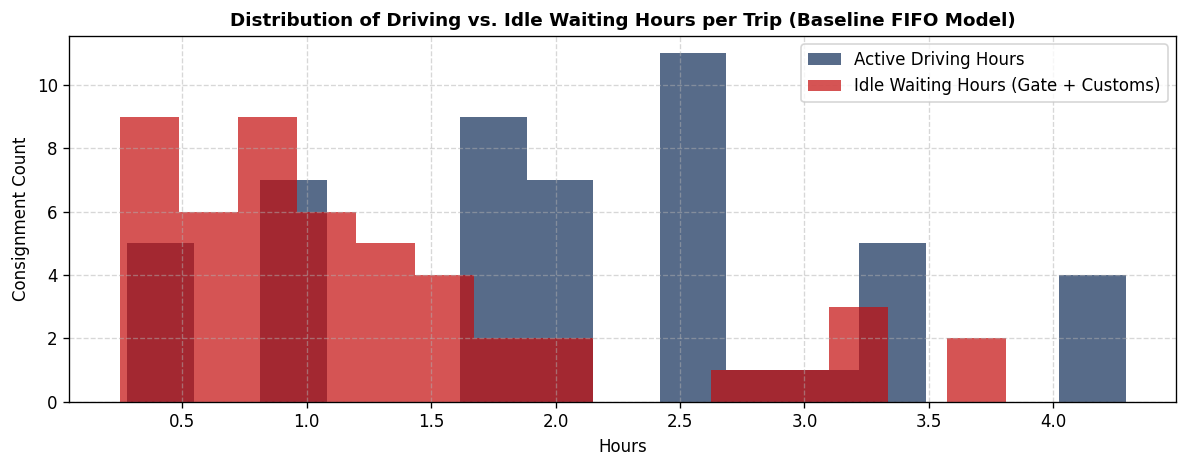

Total Hours Lost to Idle Waiting: 63.5 hours
Average Idle Waiting Time per Shipment: 1.27 hours


In [11]:
plt.figure(figsize=(10, 4), dpi=120)
plt.hist(results_df["driving_hours"], bins=15, alpha=0.7, label="Active Driving Hours", color="#102C57")
plt.hist(results_df["total_idle_hours"], bins=15, alpha=0.7, label="Idle Waiting Hours (Gate + Customs)", color="#C40C0C")

plt.title("Distribution of Driving vs. Idle Waiting Hours per Trip (Baseline FIFO Model)", fontsize=11, fontweight="bold")
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Consignment Count", fontsize=10)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Total Hours Lost to Idle Waiting: {kpis['total_idle_waiting_hours']} hours")
print(f"Average Idle Waiting Time per Shipment: {kpis['avg_idle_waiting_hours_per_trip']} hours")


## 7. Summary and Week 2 Roadmap

### Key Takeaways from Week 1:
1. **Data Ingestion Successful:** The CSO PxStat API provides continuous quarterly data for vessel arrivals, Ro-Ro units, and trade volumes from 2017 to 2026.
2. **Empirical Baseline Grounded:** Without predictive buffering, trucks waste an average of **1.27 hours per shipment** idling at port gates and customs clearance, generating **7,601.3 kg of CO2e** and costing **EUR 14,791.21** across 50 test loads.
3. **Next Steps (Week 2):**
   - Incorporate EMODnet AIS vessel density data.
   - Begin feature engineering for the Component 1 XGBoost Port Congestion Classifier.
   - Calibrate the synthetic customs clearance delay generator based on official CSO trade distributions.
